# E-COMMERCE SALES ANALYSIS PROJECT
**Tools: Python, Pandas, Matplotlib, Seaborn, SQL (SQLite)**

**Dataset: Superstore Sales (download from Kaggle)**

**STEP 1: IMPORT LIBRARIES**

In [1]:
import pandas as pd              
import matplotlib.pyplot as plt  
import seaborn as sns            
import sqlite3

**STEP 2: LOAD THE DATASET**

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
print("Shape:", df.shape)

Shape: (9994, 21)


In [5]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
print(df.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


**STEP 3: DATA CLEANING**

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

In [10]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,January
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,February
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,February
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,February


In [11]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [12]:
# Confirm clean data
print("Cleaned Shape:", df.shape)

Cleaned Shape: (9994, 24)


**STEP 4 : EXPLORATORY DATA ANALYSIS (EDA)**

In [13]:
# Total Sales, Profit, and Orders
print("\n--- Summary ---")
print("Total Sales:  $", round(df['Sales'].sum(), 2))
print("Total Profit: $", round(df['Profit'].sum(), 2))
print("Total Orders:", df['Order ID'].nunique())


--- Summary ---
Total Sales:  $ 2297200.86
Total Profit: $ 286397.02
Total Orders: 5009


In [38]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Sales by Category:\n", category_sales)

Sales by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [39]:
# Sales by Sub-Category
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print("Top Sub-Categories:\n", subcategory_sales.head(10))

Top Sub-Categories:
 Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


In [40]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
print("Monthly Sales:\n", monthly_sales.head(12))

Monthly Sales:
     Year  Month       Sales
0   2014      1  14236.8950
1   2014      2   4519.8920
2   2014      3  55691.0090
3   2014      4  28295.3450
4   2014      5  23648.2870
5   2014      6  34595.1276
6   2014      7  33946.3930
7   2014      8  27909.4685
8   2014      9  81777.3508
9   2014     10  31453.3930
10  2014     11  78628.7167
11  2014     12  69545.6205


In [41]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("Sales by Region:\n", region_sales)

Sales by Region:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [42]:
# Top 10 Cities by Sales
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Cities:\n", city_sales)

Top 10 Cities:
 City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


In [43]:
# Top 10 States by Profit
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)
print("Top 10 States by Profit:\n", state_profit)

Top 10 States by Profit:
 State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


In [44]:
# Which Ship Mode is Most Used?
ship_mode = df['Ship Mode'].value_counts()
print("Ship Mode Usage:\n", ship_mode)

Ship Mode Usage:
 Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


**STEP 5: DATA VISUALIZATION**

In [21]:
sns.set_style("whitegrid")  # Clean chart style

C:\Users\Alpesh\AppData\Local\Temp\ipykernel_19492\2489562891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')


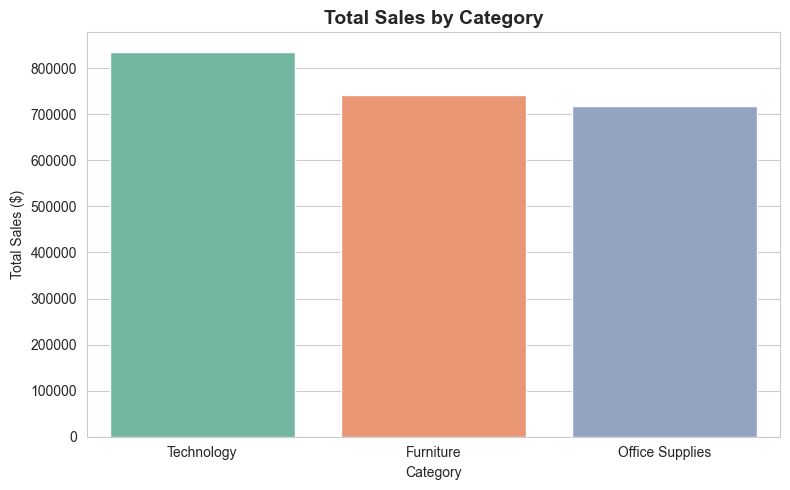

In [22]:
# Chart 1: Sales by Category (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png', dpi=150)
plt.show()

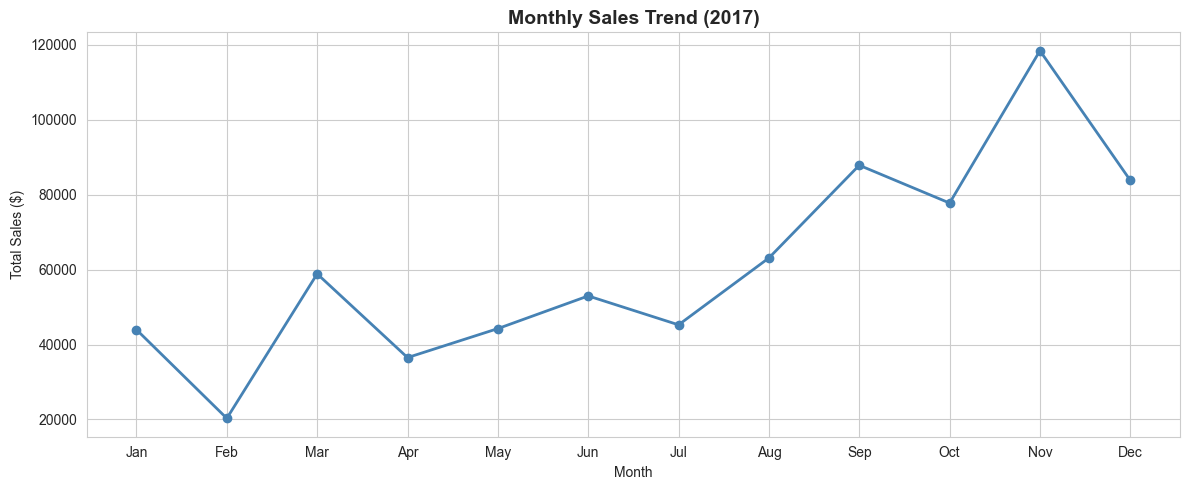

In [23]:
# Chart 2: Monthly Sales Trend (Line Chart)
plt.figure(figsize=(12, 5))
# filter for one year to keep it clean
df_2017 = df[df['Year'] == 2017]
monthly_2017 = df_2017.groupby('Month')['Sales'].sum()
plt.plot(monthly_2017.index, monthly_2017.values, marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend (2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150)
plt.show()

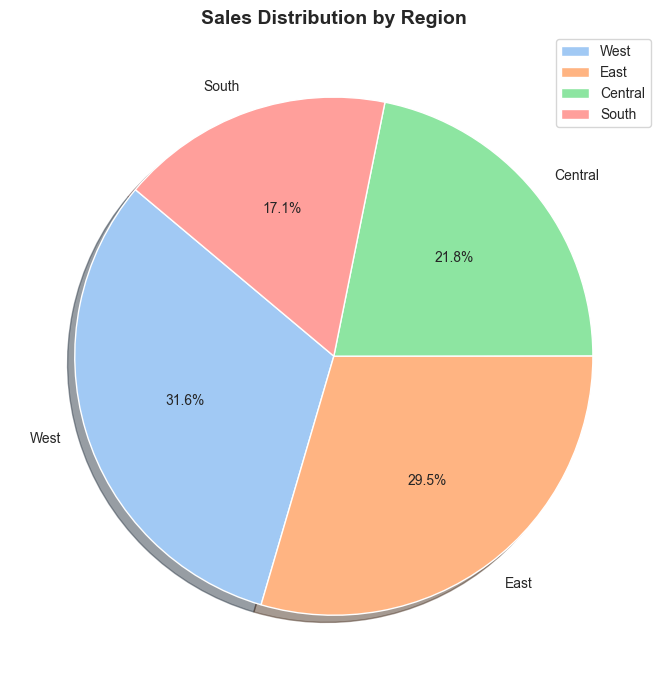

In [24]:
# Chart 3: Sales by Region (Pie Chart)
plt.figure(figsize=(7, 7))
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'), shadow=True)
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_region_pie.png', dpi=150)
plt.show()

C:\Users\Alpesh\AppData\Local\Temp\ipykernel_19492\4224483643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='Blues_r')


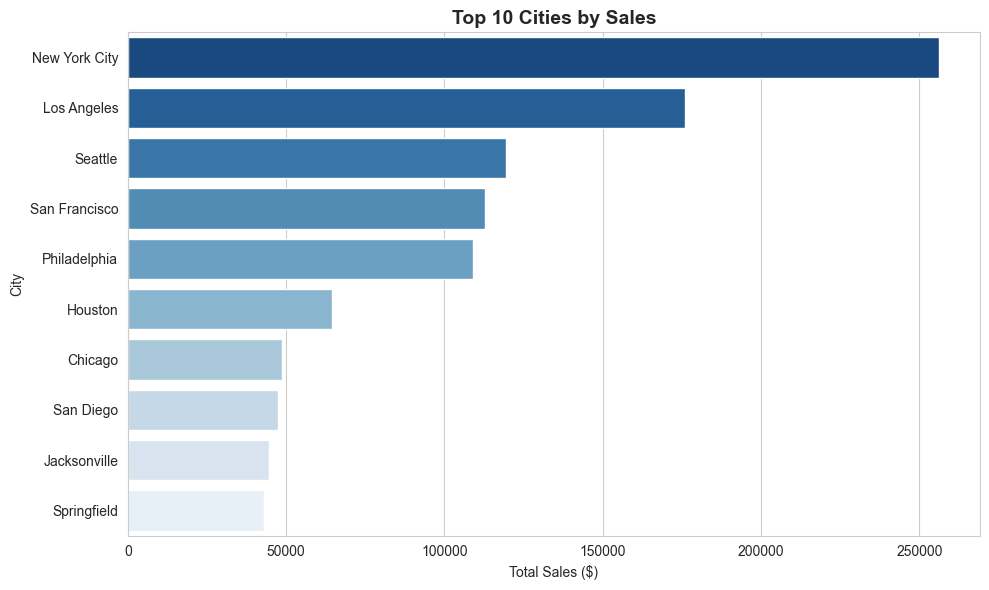

In [25]:
# Chart 4: Top 10 Cities by Sales (Horizontal Bar)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='Blues_r')
plt.title('Top 10 Cities by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('chart4_top_cities.png', dpi=150)
plt.show()

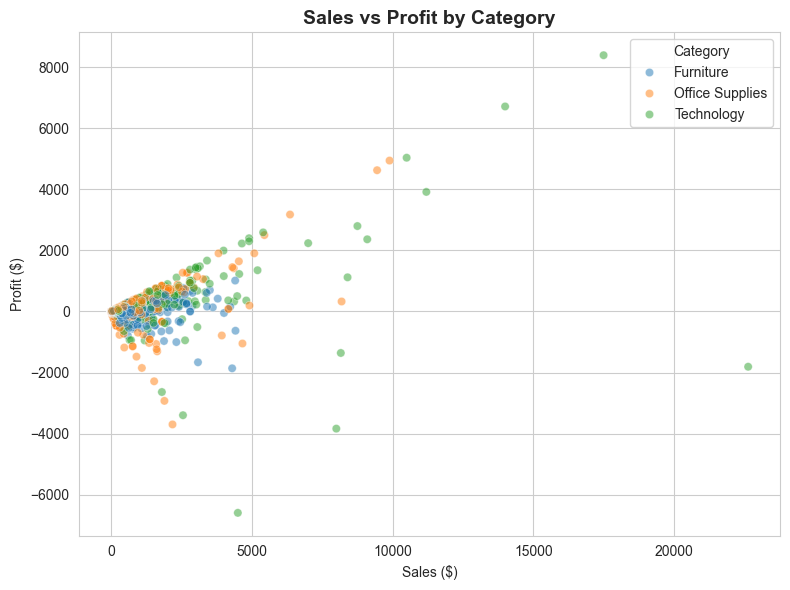

In [26]:
# Chart 5: Sales vs Profit Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.5)
plt.title('Sales vs Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('chart5_sales_vs_profit.png', dpi=150)
plt.show()

C:\Users\Alpesh\AppData\Local\Temp\ipykernel_19492\1580316795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcategory_profit.values, y=subcategory_profit.index, palette=colors)


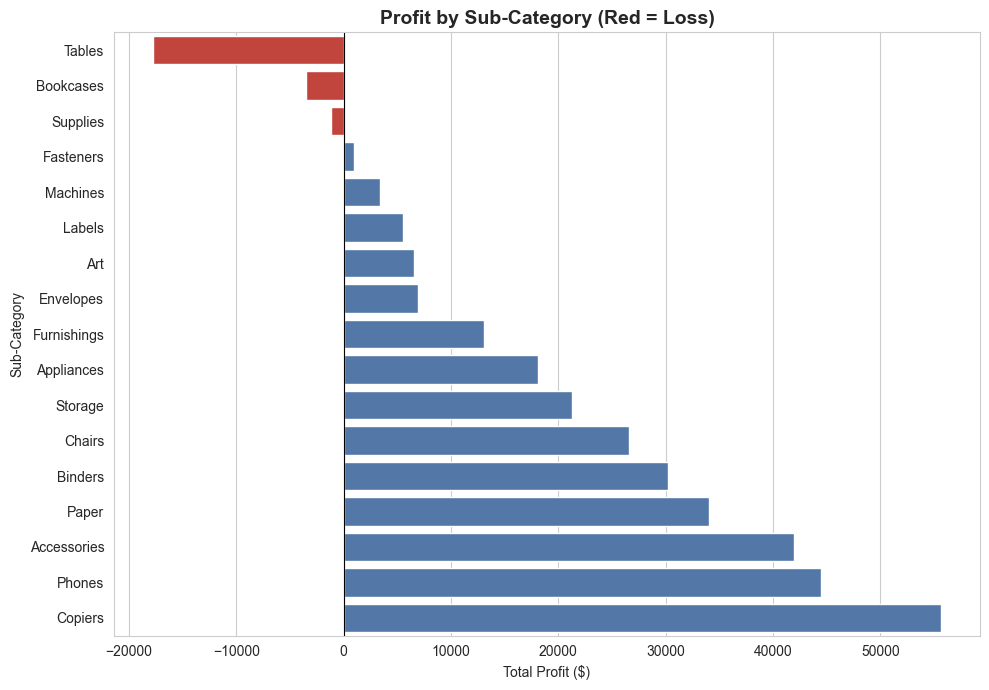

In [27]:
# Chart 6: Profit by Sub-Category
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
plt.figure(figsize=(10, 7))
colors = ['#d73027' if v < 0 else '#4575b4' for v in subcategory_profit.values]
sns.barplot(x=subcategory_profit.values, y=subcategory_profit.index, palette=colors)
plt.title('Profit by Sub-Category (Red = Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart6_profit_subcategory.png', dpi=150)
plt.show()


**STEP 6: SQL QUERIES USING SQLITE**

In [46]:
# Load dataframe into a SQLite database (in-memory)
conn = sqlite3.connect(':memory:')
# conn = sqlite3.connect('ecommerce.db') # to save data set
df.to_sql('sales', conn, index=False, if_exists='replace')

9994

In [ ]:
# Query 1: Total Sales and Profit per Category
q1 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM sales
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)
print("Sales & Profit by Category\n", q1)

Sales & Profit by Category
           Category  Total_Sales  Total_Profit
0       Technology    836154.03     145454.95
1        Furniture    741999.80      18451.27
2  Office Supplies    719047.03     122490.80


In [49]:
# Query 2: Top 5 Most Profitable Sub-Categories
q2 = pd.read_sql_query("""
    SELECT "Sub-Category",
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM sales
    GROUP BY "Sub-Category"
    ORDER BY Total_Profit DESC
    LIMIT 5
""", conn)
print("Top 5 Profitable Sub-Categories\n", q2)

Top 5 Profitable Sub-Categories
   Sub-Category  Total_Profit
0      Copiers      55617.82
1       Phones      44515.73
2  Accessories      41936.64
3        Paper      34053.57
4      Binders      30221.76


In [50]:
# Query 3: Loss-Making Sub-Categories
q3 = pd.read_sql_query("""
    SELECT "Sub-Category",
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM sales
    GROUP BY "Sub-Category"
    HAVING Total_Profit < 0
    ORDER BY Total_Profit ASC
""", conn)
print("Sub-Categories Making a Loss\n", q3)

Sub-Categories Making a Loss
   Sub-Category  Total_Profit
0       Tables     -17725.48
1    Bookcases      -3472.56
2     Supplies      -1189.10


In [51]:
# Query 4: Monthly Sales for Year 2017
q4 = pd.read_sql_query("""
    SELECT strftime('%m', "Order Date") AS Month,
           ROUND(SUM(Sales), 2) AS Monthly_Sales
    FROM sales
    WHERE strftime('%Y', "Order Date") = '2017'
    GROUP BY Month
    ORDER BY Month
""", conn)
print("Monthly Sales (2017)\n", q4)

Monthly Sales (2017)
    Month  Monthly_Sales
0     01       43971.37
1     02       20301.13
2     03       58872.35
3     04       36521.54
4     05       44261.11
5     06       52981.73
6     07       45264.42
7     08       63120.89
8     09       87866.65
9     10       77776.92
10    11      118447.82
11    12       83829.32


In [52]:
# Query 5: Top 10 Customers by Sales 
q5 = pd.read_sql_query("""
    SELECT "Customer Name",
           ROUND(SUM(Sales), 2) AS Total_Sales,
           COUNT(DISTINCT "Order ID") AS Orders
    FROM sales
    GROUP BY "Customer Name"
    ORDER BY Total_Sales DESC
    LIMIT 10
""", conn)
print("Top 10 Customers\n", q5)

Top 10 Customers
         Customer Name  Total_Sales  Orders
0         Sean Miller     25043.05       5
1        Tamara Chand     19052.22       5
2        Raymond Buch     15117.34       6
3        Tom Ashbrook     14595.62       4
4       Adrian Barton     14473.57      10
5        Ken Lonsdale     14175.23      12
6        Sanjit Chand     14142.33       9
7        Hunter Lopez     12873.30       6
8        Sanjit Engle     12209.44      11
9  Christopher Conant     12129.07       5


In [53]:
# Query 6: Which Region is Most Profitable?
q6 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Sales,
           ROUND(SUM(Profit), 2) AS Profit,
           ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Profit_Margin_Pct
    FROM sales
    GROUP BY Region
    ORDER BY Profit DESC
""", conn)
print("Profitability by Region\n", q6)

Profitability by Region
     Region      Sales     Profit  Profit_Margin_Pct
0     West  725457.82  108418.45              14.94
1     East  678781.24   91522.78              13.48
2    South  391721.91   46749.43              11.93
3  Central  501239.89   39706.36               7.92


**STEP 7: BUSINESS INSIGHTS SUMMARY**

In [35]:
print("\n======== KEY INSIGHTS ========")
print("1. Technology has highest sales but Furniture has low profit margin.")
print("2. Tables and Bookcases are loss-making sub-categories.")
print("3. West region generates highest sales overall.")
print("4. Q4 (Oct-Dec) shows peak sales every year — holiday season effect.")
print("5. Copiers are the most profitable sub-category.")


conn.close()
print("\nProject complete! Charts saved as PNG files.")


======== KEY INSIGHTS ========
1. Technology has highest sales but Furniture has low profit margin.
2. Tables and Bookcases are loss-making sub-categories.
3. West region generates highest sales overall.
4. Q4 (Oct-Dec) shows peak sales every year — holiday season effect.
5. Copiers are the most profitable sub-category.

Project complete! Charts saved as PNG files.
